# Online Retail Veri Seti — Müşteri Segmentasyonu Analizi

**Veri kaynağı:** UCI Machine Learning Repository — Online Retail (2010-2011)
**Yöntem:** RFM Analizi + K-Means Kümeleme
**Araştırma Soruları:**
1. Hangi ülkeler en yüksek geliri sağlıyor?
2. Aylık satış trendi nasıl, mevsimsellik var mı?
3. Müşteriler RFM'e göre kaç anlamlı segmente ayrılıyor ve bu segmentlerin özellikleri neler?


## 1. Kütüphaneler ve Konfigürasyon

Projede kullanılacak tüm Python kütüphaneleri bu hücrede içe aktarılır.
Matplotlib ve Seaborn için görsel stil ve varsayılan boyut ayarları yapılır.
Gereksiz uyarı mesajlarının ekrana basılması engellenir.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
import os

# Uyarıları gizle
warnings.filterwarnings('ignore')

# Grafik stili ve varsayılan boyut
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.unicode_minus'] = False   # Eksi işareti Türkçe fontlarda bozulabilir
sns.set_style('whitegrid')

# Görsellerin kaydedileceği klasör
os.makedirs('gorseller', exist_ok=True)

print("Kütüphaneler başarıyla yüklendi.")


Kütüphaneler başarıyla yüklendi.


## 2. Veri Yükleme

Ham veri seti `data/data.csv` dosyasından okunur.
Dosya Latin-1 (ISO-8859-1) kodlamasıyla kaydedildiği için `encoding='latin-1'` parametresi kullanılır.
Veri setinin boyutu, sütun tipleri ve ilk birkaç satırı ekrana yazdırılır.


In [2]:
# Veriyi oku — Latin-1 kodlaması gerekli (özel karakter içeriyor)
df = pd.read_csv('data/data.csv', encoding='latin-1')

print(f"Veri seti boyutu : {df.shape[0]:,} satır × {df.shape[1]} sütun")
print()
print("Sütun tipleri:")
print(df.dtypes)
print()
print("Eksik değer sayısı:")
print(df.isnull().sum())
print()
print("İlk 5 satır:")
df.head()


Veri seti boyutu : 541,909 satır × 8 sütun

Sütun tipleri:
InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

Eksik değer sayısı:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

İlk 5 satır:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## 3. Veri Temizleme

Ham veride eksik değerler, iade/iptal faturaları ve anlamsız fiyat/miktar satırları bulunmaktadır.
Bu hücrede sırasıyla: CustomerID eksik satırlar, "C" ile başlayan iptal faturaları,
negatif/sıfır miktar ve fiyat satırları temizlenir; ardından RFM hesabında kullanılacak
`TotalPrice` sütunu oluşturulur.


In [3]:
# Ham verinin kopyasını sakla (karşılaştırma için)
df_ham = df.copy()

# InvoiceDate sütununu datetime'a dönüştür
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Her satır için toplam geliri hesapla
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print(f"Temizlik öncesi : {len(df):,} satır")

# 1. CustomerID eksik satırları sil — RFM analizi için müşteri kimliği zorunlu
df = df.dropna(subset=['CustomerID'])
print(f"CustomerID eksik silindi  → {len(df):,} satır kaldı")

# 2. İptal faturalarını sil — InvoiceNo "C" ile başlayanlar iade kaydıdır
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
print(f"İptal faturaları silindi  → {len(df):,} satır kaldı")

# 3. Negatif veya sıfır miktarlı satırları sil — iadeler zaten iptal faturasında yakalanır
df = df[df['Quantity'] > 0]
print(f"Negatif miktar silindi    → {len(df):,} satır kaldı")

# 4. Negatif veya sıfır birim fiyatlı satırları sil — hediye/test kalemleri
df = df[df['UnitPrice'] > 0]
print(f"Geçersiz fiyat silindi    → {len(df):,} satır kaldı")

# CustomerID'yi float'tan integer'a çevir (temizlik sonrası null kalmadı)
df['CustomerID'] = df['CustomerID'].astype(int)

print()
print(f"Temizlik sonrası  : {len(df):,} satır  "
      f"({len(df_ham) - len(df):,} satır kaldırıldı, "
      f"%{(len(df_ham)-len(df))/len(df_ham)*100:.1f})")
print(f"Benzersiz müşteri : {df['CustomerID'].nunique():,}")
print(f"Benzersiz ürün    : {df['StockCode'].nunique():,}")


Temizlik öncesi : 541,909 satır
CustomerID eksik silindi  → 406,829 satır kaldı
İptal faturaları silindi  → 397,924 satır kaldı
Negatif miktar silindi    → 397,924 satır kaldı
Geçersiz fiyat silindi    → 397,884 satır kaldı

Temizlik sonrası  : 397,884 satır  (144,025 satır kaldırıldı, %26.6)
Benzersiz müşteri : 4,338
Benzersiz ürün    : 3,665


## 4. Araştırma Sorusu 1: Hangi Ülkeler En Yüksek Geliri Sağlıyor?

Veri seti büyük ölçüde İngiltere ağırlıklıdır (%91); bunu tek bir grafikte göstermek
diğer ülkelerin karşılaştırılmasını imkânsız kılar.
Bu nedenle yan yana iki panel çizilir: solda İngiltere dahil, sağda İngiltere hariç ilk 10 ülke.


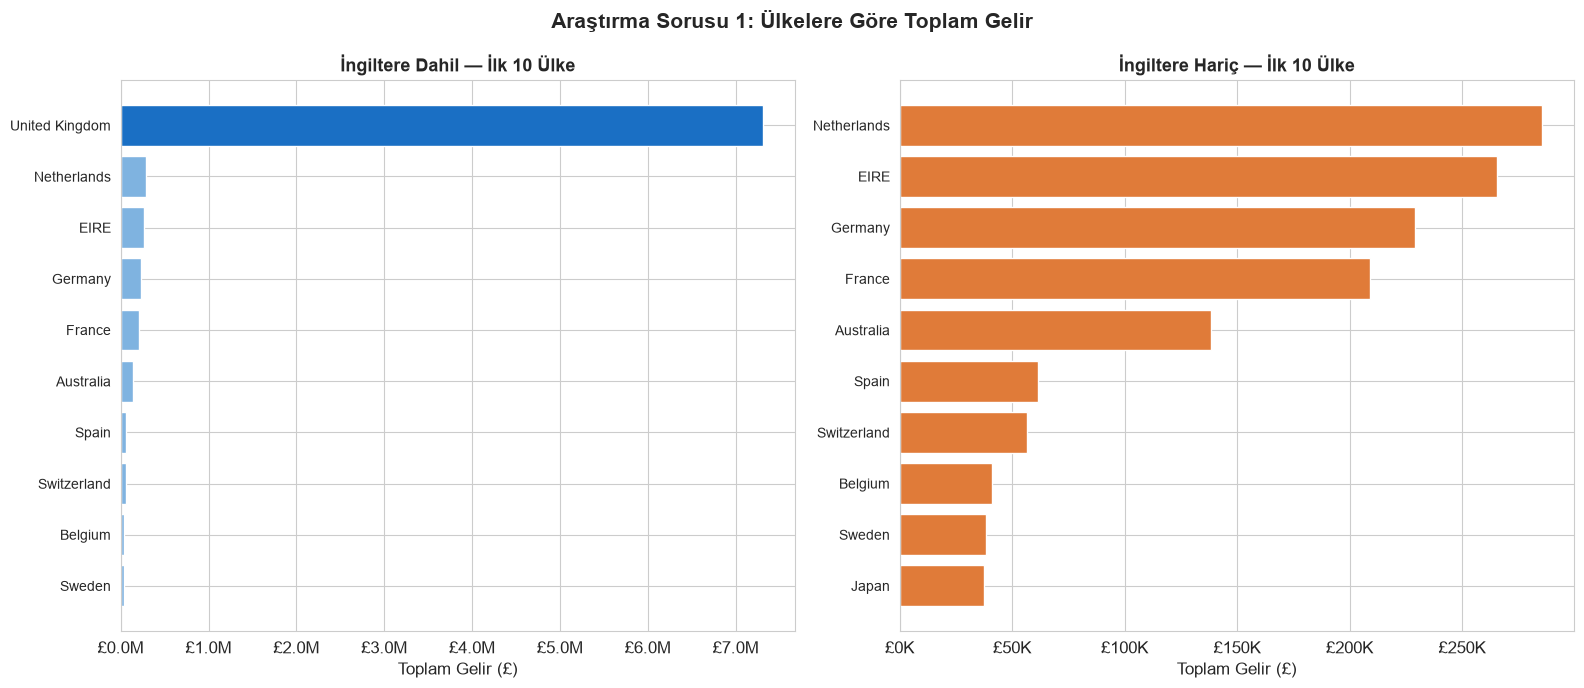

İngiltere geliri : £   7,308,392  — toplam gelirin %82.0'i

İlk 5 ülke:
  United Kingdom            £   7,308,392
  Netherlands               £     285,446
  EIRE                      £     265,546
  Germany                   £     228,867
  France                    £     209,024


In [4]:
# Ülke bazında toplam geliri hesapla ve büyükten küçüğe sırala
ulke_gelir = (
    df.groupby('Country')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Sol panel: İngiltere dahil ilk 10 ülke ──
top10_dahil = ulke_gelir.head(10)
renkler_sol = ['#1a6fc4' if c == 'United Kingdom' else '#7fb3e0'
               for c in top10_dahil.index]
axes[0].barh(top10_dahil.index[::-1], top10_dahil.values[::-1], color=renkler_sol[::-1])
axes[0].set_title('İngiltere Dahil — İlk 10 Ülke', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Toplam Gelir (£)')
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))
axes[0].tick_params(axis='y', labelsize=10)

# ── Sağ panel: İngiltere hariç ilk 10 ülke ──
top10_haric = ulke_gelir[ulke_gelir.index != 'United Kingdom'].head(10)
axes[1].barh(top10_haric.index[::-1], top10_haric.values[::-1], color='#e07b39')
axes[1].set_title('İngiltere Hariç — İlk 10 Ülke', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Toplam Gelir (£)')
axes[1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
axes[1].tick_params(axis='y', labelsize=10)

fig.suptitle('Araştırma Sorusu 1: Ülkelere Göre Toplam Gelir',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('gorseller/01_ulke_geliri.png', dpi=150, bbox_inches='tight')
plt.show()

# Sayısal özet
uk_gelir  = ulke_gelir['United Kingdom']
toplam    = ulke_gelir.sum()
print(f"İngiltere geliri : £{uk_gelir:>12,.0f}  — toplam gelirin %{uk_gelir/toplam*100:.1f}'i")
print()
print("İlk 5 ülke:")
for ulke, gelir in ulke_gelir.head(5).items():
    print(f"  {ulke:<25} £{gelir:>12,.0f}")


## 5. Araştırma Sorusu 2: Aylık Satış Trendi ve Mevsimsellik

InvoiceDate sütunundan yıl-ay bilgisi türetilerek aylık toplam ciro hesaplanır.
Çizgi grafik ve altın dolgu alanı kullanılarak trend görselleştirilir.
Zirve ay otomatik olarak tespit edilip grafikte işaretlenir.


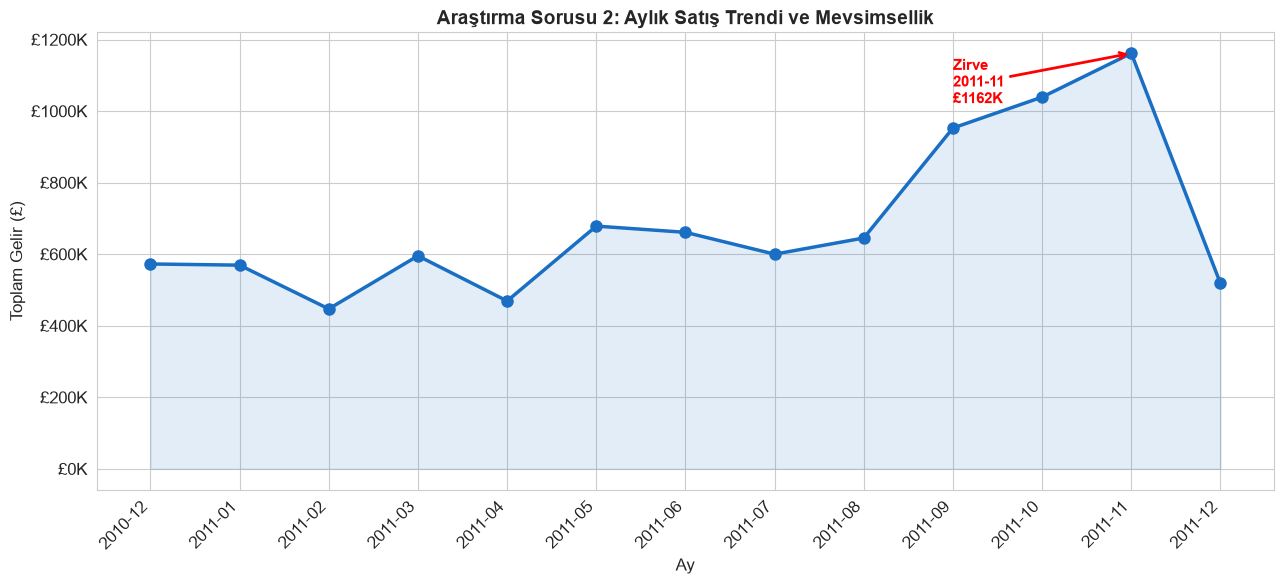

En yüksek ay : 2011-11  — £1,161,817
En düşük ay  : 2011-02  — £447,137

Ekim–Aralık 2011 ort. aylık ciro : £   906,443
Diğer aylar ort. aylık ciro       : £   619,208
Mevsimsel artış oranı             : 1.46x


In [5]:
# Fatura tarihinden yıl-ay periyodu türet
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

# Aylık toplam ciro
aylik_ciro = df.groupby('YearMonth')['TotalPrice'].sum()
x_idx      = range(len(aylik_ciro))      # Grafik için sayısal x ekseni
etiketler  = [str(p) for p in aylik_ciro.index]

fig, ax = plt.subplots(figsize=(13, 6))

# Çizgi grafik + altın dolgu alanı
ax.plot(x_idx, aylik_ciro.values,
        marker='o', linewidth=2.5, color='#1a6fc4', markersize=8, zorder=3)
ax.fill_between(x_idx, aylik_ciro.values, alpha=0.12, color='#1a6fc4')

# X ekseni etiketleri (yıl-ay)
ax.set_xticks(list(x_idx))
ax.set_xticklabels(etiketler, rotation=45, ha='right')

# Y ekseni para formatı
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda y, _: f'£{y/1e3:.0f}K'))

# En yüksek ayı kırmızı okla işaretle
max_idx = int(np.argmax(aylik_ciro.values))
ax.annotate(
    "Zirve\n" + etiketler[max_idx] + f"\n£{aylik_ciro.values[max_idx]/1e3:.0f}K",
    xy=(max_idx, aylik_ciro.values[max_idx]),
    xytext=(max_idx - 2, aylik_ciro.values[max_idx] * 0.88),
    arrowprops=dict(arrowstyle='->', color='red', lw=2),
    color='red', fontsize=11, fontweight='bold'
)

ax.set_title('Araştırma Sorusu 2: Aylık Satış Trendi ve Mevsimsellik',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Ay')
ax.set_ylabel('Toplam Gelir (£)')
plt.tight_layout()
plt.savefig('gorseller/02_aylik_trend.png', dpi=150, bbox_inches='tight')
plt.show()

# Sayısal özet
print(f"En yüksek ay : {aylik_ciro.idxmax()}  — £{aylik_ciro.max():,.0f}")
print(f"En düşük ay  : {aylik_ciro.idxmin()}  — £{aylik_ciro.min():,.0f}")

# Yıl sonu çeyreği (Ekim-Aralık) ile yılın geri kalanını karşılaştır
son_ceyrek = aylik_ciro[aylik_ciro.index.astype(str).str.contains('2011-10|2011-11|2011-12')]
diger_aylar = aylik_ciro.drop(son_ceyrek.index)
print(f"\nEkim–Aralık 2011 ort. aylık ciro : £{son_ceyrek.mean():>10,.0f}")
print(f"Diğer aylar ort. aylık ciro       : £{diger_aylar.mean():>10,.0f}")
print(f"Mevsimsel artış oranı             : {son_ceyrek.mean()/diger_aylar.mean():.2f}x")


## 6. Keşifsel Veri Analizi (EDA) — Tamamlayıcı Görseller

Ödev şartı olan dört farklı görsel türünü tamamlamak için iki ek grafik çizilir.
Görsel 3: En çok satılan 10 ürün (yatay çubuk grafik).
Görsel 4: Müşteri başına toplam harcama dağılımı — Log10 ölçeğinde histogram
(çarpık dağılımı daha okunabilir göstermek için log dönüşümü uygulanır).


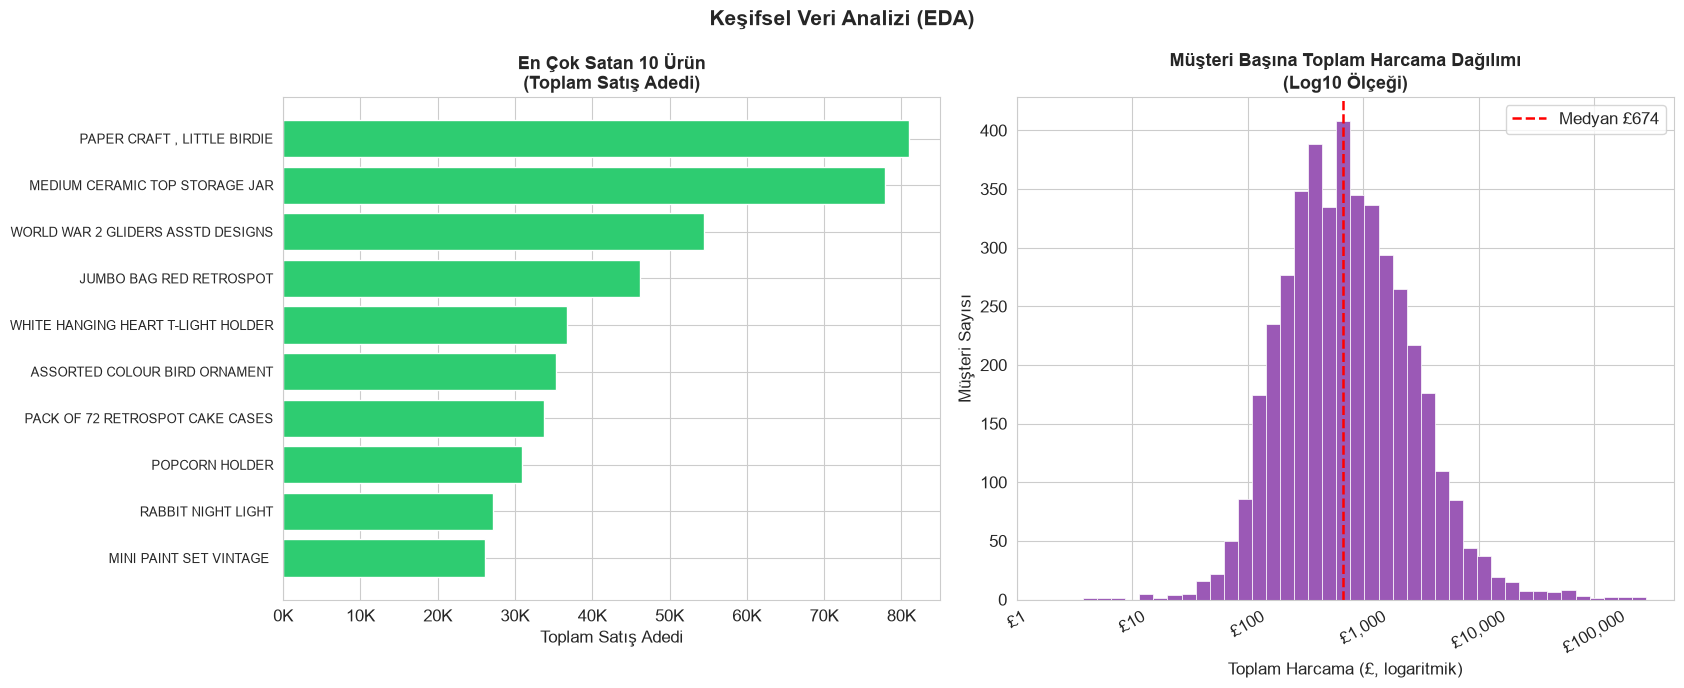

Medyan müşteri harcaması  : £    674.49
Ortalama müşteri harcaması: £  2,054.27
Maksimum müşteri harcaması: £280,206.02


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))

# ── Görsel 3: En çok satan 10 ürün (adet bazında) ──
urun_satis = (
    df.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
# Uzun ürün adlarını kısalt
kisalt = lambda s: (s[:33] + '…') if len(s) > 35 else s
urun_etiketler = [kisalt(x) for x in urun_satis.index]

axes[0].barh(urun_etiketler[::-1], urun_satis.values[::-1], color='#2ecc71')
axes[0].set_title('En Çok Satan 10 Ürün\n(Toplam Satış Adedi)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Toplam Satış Adedi')
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
axes[0].tick_params(axis='y', labelsize=9)

# ── Görsel 4: Müşteri başına harcama dağılımı (Log10 histogram) ──
musteri_harcama = df.groupby('CustomerID')['TotalPrice'].sum()
log_harcama     = np.log10(musteri_harcama[musteri_harcama > 0])

n, bins, patches = axes[1].hist(
    log_harcama, bins=40, color='#9b59b6', edgecolor='white', linewidth=0.5
)

# X eksenini gerçek para değerlerine çevir
tick_vals = np.arange(0, 6)
axes[1].set_xticks(tick_vals)
axes[1].set_xticklabels([f'£{10**t:,.0f}' for t in tick_vals], rotation=30)

axes[1].set_title('Müşteri Başına Toplam Harcama Dağılımı\n(Log10 Ölçeği)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Toplam Harcama (£, logaritmik)')
axes[1].set_ylabel('Müşteri Sayısı')

# Medyan çizgisi
medyan = np.log10(musteri_harcama.median())
axes[1].axvline(medyan, color='red', linestyle='--', linewidth=1.8,
                label=f'Medyan £{musteri_harcama.median():,.0f}')
axes[1].legend()

fig.suptitle('Keşifsel Veri Analizi (EDA)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('gorseller/03_eda_gorselleri.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Medyan müşteri harcaması  : £{musteri_harcama.median():>10,.2f}")
print(f"Ortalama müşteri harcaması: £{musteri_harcama.mean():>10,.2f}")
print(f"Maksimum müşteri harcaması: £{musteri_harcama.max():>10,.2f}")


## 7. RFM Metrikleri Hesaplama

RFM analizi için her müşteriye üç metrik hesaplanır:
- **Recency:** Referans tarihinden (son işlem + 1 gün) bu yana kaç gün geçti — düşükse müşteri daha aktif.
- **Frequency:** Kaç farklı fatura kestiği — yüksekse müşteri daha sadık.
- **Monetary:** Toplam harcaması (£) — yüksekse müşteri daha değerli.


In [7]:
# Referans tarihi: son işlem tarihinin bir gün sonrası
referans_tarihi = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Referans tarihi: {referans_tarihi.date()}")

# Her müşteri için RFM değerlerini hesapla
rfm = (
    df.groupby('CustomerID')
    .agg(
        Recency  =('InvoiceDate', lambda x: (referans_tarihi - x.max()).days),
        Frequency=('InvoiceNo',   'nunique'),   # Benzersiz fatura sayısı
        Monetary =('TotalPrice',  'sum')        # Toplam harcama (£)
    )
    .reset_index()
)

print(f"\nRFM tablosu oluşturuldu: {len(rfm):,} müşteri")
print()
print("RFM özet istatistikleri:")
print(rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2))

rfm.head(10)


Referans tarihi: 2011-12-10

RFM tablosu oluşturuldu: 4,338 müşteri

RFM özet istatistikleri:
       Recency  Frequency   Monetary
count  4338.00    4338.00    4338.00
mean     92.54       4.27    2054.27
std     100.01       7.70    8989.23
min       1.00       1.00       3.75
25%      18.00       1.00     307.41
50%      51.00       2.00     674.48
75%     142.00       5.00    1661.74
max     374.00     209.00  280206.02


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40
5,12352,36,8,2506.04
6,12353,204,1,89.00
7,12354,232,1,1079.40
8,12355,214,1,459.40
9,12356,23,3,2811.43


## 8. Araştırma Sorusu 3: K-Means ile Müşteri Segmentasyonu

RFM değerleri önce `StandardScaler` ile standartlaştırılır (farklı ölçekteki değerlerin
K-Means'ı olumsuz etkilememesi için).
Elbow yöntemiyle optimal küme sayısı belirlenir, ardından K-Means uygulanır.
Her kümeye iş anlamı taşıyan bir etiket atanır: Şampiyonlar, Sadık Müşteriler, Risk Altındakiler, Kayıp Müşteriler.


Segment ortalamaları:
                   Recency  Frequency  Monetary
Segment_Etiketi                                
Kayıp Müşteriler     248.1        1.6     480.6
Risk Altındakiler     43.7        3.7    1359.0
Sadık Müşteriler      15.5       22.3   12709.1
Şampiyonlar            7.4       82.5  127338.3

Segment büyüklükleri:
Segment_Etiketi
Risk Altındakiler    3054
Kayıp Müşteriler     1067
Sadık Müşteriler      204
Şampiyonlar            13
Name: count, dtype: int64


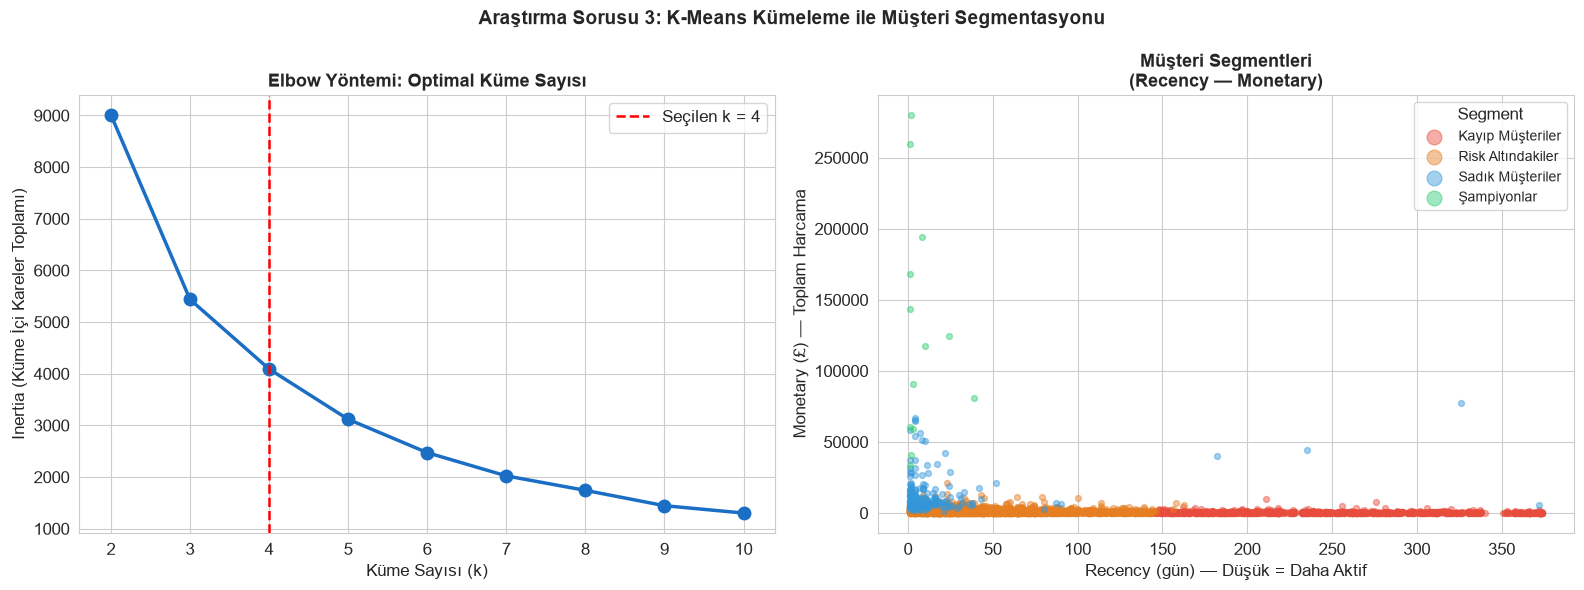

In [8]:
# ── Ölçekleme ──
scaler     = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

# ── Elbow Yöntemi: optimal k'yı bul ──
inertia  = []
k_aralik = range(2, 11)

for k in k_aralik:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

# ── Görsel 5: Elbow + Görsel 6: Scatter ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Elbow grafiği
axes[0].plot(list(k_aralik), inertia, marker='o', linewidth=2.5,
             color='#1a6fc4', markersize=9)
axes[0].axvline(x=4, color='red', linestyle='--', linewidth=1.8,
                label='Seçilen k = 4')
axes[0].set_title('Elbow Yöntemi: Optimal Küme Sayısı', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Küme Sayısı (k)')
axes[0].set_ylabel('Inertia (Küme İçi Kareler Toplamı)')
axes[0].set_xticks(list(k_aralik))
axes[0].legend()

# ── K-Means (k=4) ──
kmeans          = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Segment']  = kmeans.fit_predict(rfm_scaled)

# Segmentlere iş etiketi ver — Monetary ortalamasına göre sırala
monetary_ort  = rfm.groupby('Segment')['Monetary'].mean().sort_values()
etiket_map    = {
    monetary_ort.index[0]: 'Kayıp Müşteriler',
    monetary_ort.index[1]: 'Risk Altındakiler',
    monetary_ort.index[2]: 'Sadık Müşteriler',
    monetary_ort.index[3]: 'Şampiyonlar',
}
rfm['Segment_Etiketi'] = rfm['Segment'].map(etiket_map)

# Segment özet tablosu
print("Segment ortalamaları:")
ozet = rfm.groupby('Segment_Etiketi')[['Recency', 'Frequency', 'Monetary']].mean().round(1)
print(ozet)
print()
print("Segment büyüklükleri:")
print(rfm['Segment_Etiketi'].value_counts())

# Scatter — Recency vs Monetary, segmente göre renkli
renk_paleti = {
    'Şampiyonlar'       : '#2ecc71',
    'Sadık Müşteriler'  : '#3498db',
    'Risk Altındakiler' : '#e67e22',
    'Kayıp Müşteriler'  : '#e74c3c',
}
for etiket, grup in rfm.groupby('Segment_Etiketi'):
    axes[1].scatter(
        grup['Recency'], grup['Monetary'],
        label=etiket, alpha=0.45, s=18,
        color=renk_paleti[etiket]
    )

axes[1].set_title('Müşteri Segmentleri\n(Recency — Monetary)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Recency (gün) — Düşük = Daha Aktif')
axes[1].set_ylabel('Monetary (£) — Toplam Harcama')
axes[1].legend(title='Segment', markerscale=2.5, fontsize=10)

fig.suptitle('Araştırma Sorusu 3: K-Means Kümeleme ile Müşteri Segmentasyonu',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('gorseller/04_kmeans_segmentasyon.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Sonuçlar, Pazarlama Önerileri ve Proje Kısıtlılıkları

Bu hücrede üç araştırma sorusuna verilen cevaplar özetlenir.
Her müşteri segmenti için iş dünyasına yönelik somut pazarlama önerileri sunulur.
Son olarak projenin metodolojik kısıtlılıkları dürüstçe belirtilir.


In [9]:
ayirici = "=" * 62

# ── Araştırma Sorusu 1 ──
ulke_gelir  = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)
uk_gelir    = ulke_gelir['United Kingdom']
toplam_gelir = ulke_gelir.sum()

print(ayirici)
print(" ARAŞTIRMA SORUSU 1: Ülke Gelirleri")
print(ayirici)
print(f"  İngiltere toplam gelirin %{uk_gelir/toplam_gelir*100:.1f}'ini oluşturuyor.")
print(f"  İngiltere dışında en yüksek gelir sağlayan ülkeler:")
for ulke, gelir in ulke_gelir[ulke_gelir.index != 'United Kingdom'].head(3).items():
    print(f"    {ulke:<25} £{gelir:>10,.0f}")

# ── Araştırma Sorusu 2 ──
aylik_ciro = df.groupby('YearMonth')['TotalPrice'].sum()

print()
print(ayirici)
print(" ARAŞTIRMA SORUSU 2: Aylık Trend ve Mevsimsellik")
print(ayirici)
print(f"  En yüksek ciro: {aylik_ciro.idxmax()} — £{aylik_ciro.max():,.0f}")
son_ceyrek  = aylik_ciro[aylik_ciro.index.astype(str).str.contains('2011-10|2011-11|2011-12')]
diger       = aylik_ciro.drop(son_ceyrek.index)
print(f"  Ekim–Aralık 2011, diğer aylara göre {son_ceyrek.mean()/diger.mean():.2f}x daha yüksek.")
print("  Belirgin mevsimsel zirve Kasım–Aralık döneminde (tatil/yılbaşı alışverişi).")

# ── Araştırma Sorusu 3 ──
print()
print(ayirici)
print(" ARAŞTIRMA SORUSU 3: K-Means Müşteri Segmentasyonu (k=4)")
print(ayirici)
siralama = ['Şampiyonlar', 'Sadık Müşteriler', 'Risk Altındakiler', 'Kayıp Müşteriler']
for etiket in siralama:
    grup = rfm[rfm['Segment_Etiketi'] == etiket]
    print(f"  [{etiket}]  —  {len(grup):,} müşteri")
    print(f"    Ort. Recency  : {grup['Recency'].mean():.0f} gün")
    print(f"    Ort. Frequency: {grup['Frequency'].mean():.1f} fatura")
    print(f"    Ort. Monetary : £{grup['Monetary'].mean():,.0f}")
    print()

# ── Pazarlama Önerileri ──
print(ayirici)
print(" PAZARLAMa ÖNERİLERİ")
print(ayirici)
print("  Şampiyonlar       → Özel sadakat programı, erken erişim ve VIP kampanyaları")
print("  Sadık Müşteriler  → Çapraz satış fırsatları, kişiselleştirilmiş öneriler")
print("  Risk Altındakiler → Geri kazanma e-postası, süreli indirim kodu")
print("  Kayıp Müşteriler  → Son şans kampanyası veya pasif müşteri olarak kabul")

# ── Proje Kısıtlılıkları ──
print()
print(ayirici)
print(" PROJE KISITLILIKLARI")
print(ayirici)
print("  • Veri yalnızca 13 ay (2010-12 → 2011-12) kapsıyor; uzun vadeli trend sınırlı.")
print("  • CustomerID eksik olan ~%25'lik dilim analizin dışında kaldı.")
print("  • Veri seti İngiltere ağırlıklı (%91); uluslararası bulgular temkinli yorumlanmalı.")
print("  • K-Means Euclidean mesafeye dayanır; ölçek farklılıkları StandardScaler ile giderildi.")


 ARAŞTIRMA SORUSU 1: Ülke Gelirleri
  İngiltere toplam gelirin %82.0'ini oluşturuyor.
  İngiltere dışında en yüksek gelir sağlayan ülkeler:
    Netherlands               £   285,446
    EIRE                      £   265,546
    Germany                   £   228,867

 ARAŞTIRMA SORUSU 2: Aylık Trend ve Mevsimsellik
  En yüksek ciro: 2011-11 — £1,161,817
  Ekim–Aralık 2011, diğer aylara göre 1.46x daha yüksek.
  Belirgin mevsimsel zirve Kasım–Aralık döneminde (tatil/yılbaşı alışverişi).

 ARAŞTIRMA SORUSU 3: K-Means Müşteri Segmentasyonu (k=4)
  [Şampiyonlar]  —  13 müşteri
    Ort. Recency  : 7 gün
    Ort. Frequency: 82.5 fatura
    Ort. Monetary : £127,338

  [Sadık Müşteriler]  —  204 müşteri
    Ort. Recency  : 16 gün
    Ort. Frequency: 22.3 fatura
    Ort. Monetary : £12,709

  [Risk Altındakiler]  —  3,054 müşteri
    Ort. Recency  : 44 gün
    Ort. Frequency: 3.7 fatura
    Ort. Monetary : £1,359

  [Kayıp Müşteriler]  —  1,067 müşteri
    Ort. Recency  : 248 gün
    Ort. Freque